In [8]:
import uproot  # ROOT dosyalarını Python ile okumak/yazmak için ana kütüphane  # modül: uproot

path = "../build/Veri_t0.root"  # Okunacak ROOT dosyasının adı/yolu  # değişken: path

f = uproot.open(path)  # ROOT dosyasını açar (içindeki objelere erişim sağlar)  # fonksiyon: uproot.open

print("DOSYA:", path)  # Dosya adını ekrana basar  # print bloğu
print("ICINDEKILER (keys):")  # İçindeki objeleri listeleyeceğiz  # açıklama satırı

for k in f.keys():  # Dosya içindeki objelerin anahtarlarını (isimlerini) döner  # method: f.keys
    print(" -", k)  # Her anahtarı satır satır yazdırır  # çıktı üretimi


DOSYA: ../build/Veri_t0.root
ICINDEKILER (keys):
 - Olaylar;1


In [5]:
import uproot  # ROOT dosyası okuma/yazma kütüphanesi  # modül: uproot

path = "../build/Veri_t0.root"  # ROOT dosya yolu  # değişken: path
tree_name = "Olaylar"  # Açacağımız TTree adı (keys'ten aldık)  # değişken: tree_name

tree = uproot.open(f"{path}:{tree_name}")  # Dosya:Tree kısayolu ile direkt TTree açar  # fonksiyon: uproot.open

print("TREE CLASS:", tree.classname)  # Objeye ait ROOT sınıf adını yazar  # property: classname
print("ENTRY (olay) SAYISI:", tree.num_entries)  # TTree içindeki toplam event sayısı  # property: num_entries

print("\nBRANCH (kolon) LISTESI:")  # Branch isimlerini yazdırma başlığı  # çıktı bloğu
for b in tree.keys():  # TTree içindeki branch isimlerini döner  # method: tree.keys
    print(" -", b)  # Her branch adını satır satır yazdırır  # çıktı üretimi

print("\nTIPLERIYLE BIRLIKTE (ozet):")  # Branch + tipleri tek ekranda görmek için  # açıklama satırı
tree.show()  # Branch isimlerini ve veri tiplerini tablo gibi gösterir  # method: tree.show


TREE CLASS: TTree
ENTRY (olay) SAYISI: 7461.0

BRANCH (kolon) LISTESI:
 - Enerji_MeV

TIPLERIYLE BIRLIKTE (ozet):
name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
Enerji_MeV           | double                   | AsDtype('>f8')


In [6]:
import uproot  # ROOT dosyası okuma  # modül: uproot
import awkward as ak  # Veriyi dizi yapısında taşımak (jagged uyumlu)  # modül: awkward
import numpy as np  # Sayısal işlemler ve NumPy array'e çevirme  # modül: numpy

path = "../build/Veri_t0.root"  # ROOT dosya yolu  # değişken: path
tree_name = "Olaylar"  # TTree adı  # değişken: tree_name
branch = "Enerji_MeV"  # Okuyacağımız branch  # değişken: branch

tree = uproot.open(f"{path}:{tree_name}")  # Dosyadan TTree açar  # fonksiyon: uproot.open

arr_ak = tree.arrays([branch], library="ak")  # Branch'i Awkward olarak okur (kolon adıyla gelir)  # method: tree.arrays
e_ak = arr_ak[branch]  # Sadece Enerji_MeV kolonunu seçer  # kolon seçimi

print("TIP (Awkward):", type(e_ak))  # Verinin tipini gösterir  # type kontrol
print("ILK 10 DEGER (Awkward):", e_ak[:10])  # İlk 10 enerji değerini basar  # dilimleme

e_np = ak.to_numpy(e_ak)  # Awkward -> NumPy dönüştürür  # fonksiyon: ak.to_numpy
print("\nTIP (NumPy):", type(e_np))  # NumPy tipini gösterir  # type kontrol
print("BOYUT:", e_np.shape)  # Kaç eleman var (7461 bekleriz)  # shape
print("ILK 10 DEGER (NumPy):", e_np[:10])  # İlk 10 değer  # dilimleme

print("\nMIN / MAX / ORT:")  # Özet istatistik başlığı  # çıktı bloğu
print("min =", float(np.min(e_np)))  # Minimum enerji  # numpy min
print("max =", float(np.max(e_np)))  # Maksimum enerji  # numpy max
print("mean =", float(np.mean(e_np)))  # Ortalama enerji  # numpy mean


TIP (Awkward): <class 'awkward.highlevel.Array'>
ILK 10 DEGER (Awkward): [1.33, 1.17, 1.17, 1.17, 1.33, 1.17, 1.17, 1.33, 0.758, 1.17]

TIP (NumPy): <class 'numpy.ndarray'>
BOYUT: (7461,)
ILK 10 DEGER (NumPy): [1.3325    1.1732    1.1732    1.1732    1.3325    1.1732    1.1732
 1.3325    0.7583795 1.1732   ]

MIN / MAX / ORT:
min = 0.00026266295102539416
max = 1.3325000000000005
mean = 1.0681887025999703


In [9]:
import uproot  # ROOT dosyası okumak için  # modül: uproot
import awkward as ak  # Awkward -> NumPy dönüşümü için  # modül: awkward
import numpy as np  # histogram ve istatistik için  # modül: numpy

path = "../build/Veri_t0.root"  # ROOT dosya yolu  # değişken: path
tree_name = "Olaylar"  # TTree adı  # değişken: tree_name
branch = "Enerji_MeV"  # Enerji branch adı  # değişken: branch

tree = uproot.open(f"{path}:{tree_name}")  # TTree açar  # fonksiyon: uproot.open
e_ak = tree.arrays([branch], library="ak")[branch]  # Branch'i Awkward olarak okur ve seçer  # method: tree.arrays
e = ak.to_numpy(e_ak)  # Awkward -> NumPy çevirir  # fonksiyon: ak.to_numpy

emin = float(np.min(e))  # minimum enerji  # numpy min
emax = float(np.max(e))  # maksimum enerji  # numpy max
print("emin, emax =", emin, emax)  # aralığı gör  # çıktı

bin_width = 0.001  # bin genişliği (MeV) - tepe ayırmak için ince seçtik  # değişken: bin_width
bins = np.arange(0.0, emax + bin_width, bin_width)  # 0'dan max'a bin kenarları üretir  # numpy arange
hist, edges = np.histogram(e, bins=bins)  # histogram sayımlarını ve bin kenarlarını hesaplar  # numpy histogram

centers = 0.5 * (edges[:-1] + edges[1:])  # bin merkezlerini hesaplar  # bin merkezi hesabı

topN = 10  # en yüksek sayımlı ilk N bin  # değişken: topN
idx = np.argsort(hist)[-topN:][::-1]  # sayımı en büyük binleri sırala  # numpy argsort

print("\nEN YUKSEK SAYIMLI BIN'LER (tepe adaylari):")  # başlık  # çıktı bloğu
for i in idx:  # seçilen bin indekslerinde dolaşır  # döngü
    print(f"E~{centers[i]:.4f} MeV  count={hist[i]}")  # bin merkezi ve sayımı yazar  # formatlı çıktı

print("\nTOPLAM SAYIM =", int(np.sum(hist)))  # histogram toplamı (event sayısı ile uyumlu olmalı)  # kontrol çıktısı


emin, emax = 0.00026266295102539416 1.3325000000000005

EN YUKSEK SAYIMLI BIN'LER (tepe adaylari):
E~1.1735 MeV  count=2660
E~1.3325 MeV  count=2569
E~0.8215 MeV  count=13
E~0.9255 MeV  count=8
E~0.9595 MeV  count=7
E~0.8145 MeV  count=7
E~0.8715 MeV  count=7
E~0.9065 MeV  count=7
E~0.9575 MeV  count=7
E~0.9605 MeV  count=7

TOPLAM SAYIM = 7461


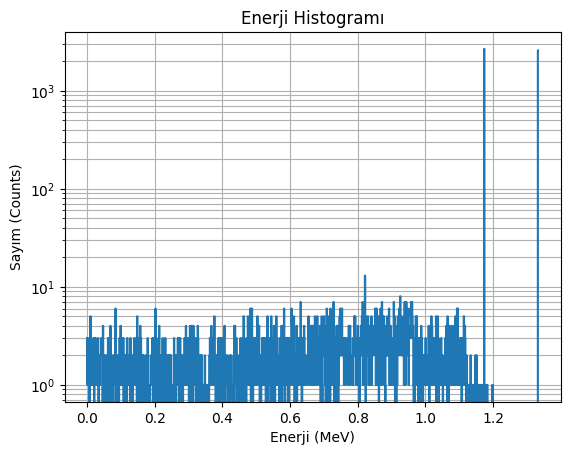

Bulunan 2 tepe (bin merkezi): [1.1735 1.3325]
Tepe ~ 1.1735 MeV | ROI=±0.005 MeV | sayim=2661 | centroid=1.17350 MeV
Tepe ~ 1.3325 MeV | ROI=±0.005 MeV | sayim=2569 | centroid=1.33250 MeV


In [10]:
import uproot  # ROOT dosyası okumak/yazmak için  # modül: uproot
import awkward as ak  # Awkward -> NumPy dönüşümü için  # modül: awkward
import numpy as np  # histogram/hesaplar için  # modül: numpy
import matplotlib.pyplot as plt  # grafik çizmek için  # modül: matplotlib.pyplot

path = "../build/Veri_t0.root"  # ROOT dosya yolu  # değişken: path
tree_name = "Olaylar"  # TTree adı  # değişken: tree_name
branch = "Enerji_MeV"  # enerji branch adı  # değişken: branch

tree = uproot.open(f"{path}:{tree_name}")  # Dosya:Tree kısayolu ile TTree açar  # fonksiyon: uproot.open
e_ak = tree.arrays([branch], library="ak")[branch]  # Branch'i Awkward olarak okur ve seçer  # method: tree.arrays
e = ak.to_numpy(e_ak)  # Awkward -> NumPy çevirir  # fonksiyon: ak.to_numpy

bin_width = 0.001  # bin genişliği (MeV)  # değişken: bin_width
emax = float(np.max(e))  # maksimum enerji  # numpy max
bins = np.arange(0.0, emax + bin_width, bin_width)  # bin kenarlarını üretir  # numpy arange
hist, edges = np.histogram(e, bins=bins)  # histogram sayımını hesaplar  # numpy histogram
centers = 0.5 * (edges[:-1] + edges[1:])  # bin merkezlerini hesaplar  # aritmetik hesap

# --- 1) GRAFİK: histogramı çiz ---  # blok: çizim
plt.figure()  # yeni figür oluşturur  # matplotlib figure
plt.step(centers, hist, where="mid")  # bin merkezlerinde step histogram çizer  # method: plt.step
plt.xlabel("Enerji (MeV)")  # x ekseni etiketi  # method: plt.xlabel
plt.ylabel("Sayım (Counts)")  # y ekseni etiketi  # method: plt.ylabel
plt.title("Enerji Histogramı")  # başlık  # method: plt.title
plt.yscale("log")  # küçük sayımları görmek için log ölçek  # method: plt.yscale
plt.grid(True, which="both")  # ızgara (logda okunabilirlik)  # method: plt.grid
plt.show()  # grafiği gösterir  # method: plt.show

# --- 2) TEPELERİ BUL: en yüksek 2 bin merkezi ---  # blok: tepe bulma
top2_idx = np.argsort(hist)[-2:][::-1]  # en yüksek 2 bin indeksini bulur  # numpy argsort
peakE = np.sort(centers[top2_idx])  # enerjiye göre küçükten büyüğe sıralar  # numpy sort

print("Bulunan 2 tepe (bin merkezi):", peakE)  # iki tepenin enerjisini basar  # çıktı

# --- 3) ROI (pencere) ile sayım + centroid ---  # blok: ROI hesabı
half_window = 0.005  # ROI yarı-genişliği (MeV) -> ±0.005 = ±5 keV  # değişken: half_window

for p in peakE:  # her tepe için döngü  # döngü bloğu
    mask = (centers >= (p - half_window)) & (centers <= (p + half_window))  # ROI içindeki binleri seçer  # boolean maske
    roi_counts = int(np.sum(hist[mask]))  # ROI içindeki toplam sayımı hesaplar  # numpy sum
    if roi_counts > 0:  # sıfır bölme olmasın diye kontrol  # koşul bloğu
        centroid = float(np.sum(centers[mask] * hist[mask]) / np.sum(hist[mask]))  # ağırlıklı ortalama enerji (centroid)  # hesap
    else:
        centroid = float("nan")  # sayım yoksa NaN  # güvenli değer

    print(f"Tepe ~ {p:.4f} MeV | ROI=±{half_window:.3f} MeV | sayim={roi_counts} | centroid={centroid:.5f} MeV")  # özet  # formatlı çıktı
